In [ ]:
import scanpy as sc
import os   
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
import pandas as pd

/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = "./data/Kim_lung/"
dataset = data_dir.split('/')[-2].lower()

In [3]:
scGPT = sc.read_h5ad(data_dir + "scGPT_" + dataset + ".h5ad")
scGPT_cancer = sc.read_h5ad(data_dir + "scGPT_cancer_" + dataset + ".h5ad")
scFoundation = sc.read_h5ad(data_dir + "scFoundation_" + dataset + ".h5ad")
CancerGPT = sc.read_h5ad(data_dir + "CancerGPT_github_" + dataset + ".h5ad")
medium = sc.read_h5ad(data_dir + "CancerGPT_medium_" + dataset + ".h5ad")
condtech_done = sc.read_h5ad(data_dir + "CancerGPT_condtech_done_" + dataset + ".h5ad")

adata = CancerGPT
adata.obsm["scGPT"] = scGPT.obsm["X_scGPT"]
adata.obsm["scGPT_cancer"] = scGPT_cancer.obsm["X_scGPT"]
adata.obsm["scFoundation"] = scFoundation.obsm["scfoundation_embedding"]
adata.obsm["Old code"] = CancerGPT.obsm["CancerGPT"]
adata.obsm["New code"] = medium.obsm["CancerGPT"]
adata.obsm["New code (cond)"] = condtech_done.obsm["CancerGPT"]

del(adata.obsm["CancerGPT"])

all_keys = list(adata.obsm.keys())

In [3]:
CancerGPT = sc.read_h5ad(data_dir + "CancerGPT_github_" + dataset + ".h5ad")
bigger = sc.read_h5ad(data_dir + "CancerGPT_bigger_" + dataset + ".h5ad")
medium = sc.read_h5ad(data_dir + "CancerGPT_medium_" + dataset + ".h5ad")
pcpt = sc.read_h5ad(data_dir + "CancerGPT_pcpt_" + dataset + ".h5ad")
hid4x = sc.read_h5ad(data_dir + "CancerGPT_hid4x_" + dataset + ".h5ad")
fewerheads = sc.read_h5ad(data_dir + "CancerGPT_fewerheads_" + dataset + ".h5ad")
gelu_prenorm = sc.read_h5ad(data_dir + "CancerGPT_gelu_prenorm_" + dataset + ".h5ad")
pcpt_bs128 = sc.read_h5ad(data_dir + "CancerGPT_pcpt_bs128_" + dataset + ".h5ad")
bigger_6heads = sc.read_h5ad(data_dir + "CancerGPT_bigger_6heads_" + dataset + ".h5ad")
condtech_early = sc.read_h5ad(data_dir + "CancerGPT_condtech_early_" + dataset + ".h5ad")
condtech_done = sc.read_h5ad(data_dir + "CancerGPT_condtech_done_" + dataset + ".h5ad")
condtech_coarse = sc.read_h5ad(data_dir + "CancerGPT_condtech_coarse_" + dataset + ".h5ad")
coarse = sc.read_h5ad(data_dir + "CancerGPT_coarse_" + dataset + ".h5ad")
brain = sc.read_h5ad(data_dir + "CancerGPT_brain_" + dataset + ".h5ad")
big = sc.read_h5ad(data_dir + "CancerGPT_big_" + dataset + ".h5ad")
pcpt_lobs = sc.read_h5ad(data_dir + "CancerGPT_pcpt_lobs_" + dataset + ".h5ad")

adata = CancerGPT
adata.obsm["github"] = CancerGPT.obsm["CancerGPT"]
adata.obsm["bigger"] = bigger.obsm["CancerGPT"]
adata.obsm["medium"] = medium.obsm["CancerGPT"]
adata.obsm["pcpt"] = pcpt.obsm["CancerGPT"]
adata.obsm["hid4x"] = hid4x.obsm["CancerGPT"]
adata.obsm["fewerheads"] = fewerheads.obsm["CancerGPT"]
adata.obsm["gelu_prenorm"] = gelu_prenorm.obsm["CancerGPT"]
adata.obsm["pcpt_bs128"] = pcpt_bs128.obsm["CancerGPT"]
adata.obsm["bigger_6heads"] = bigger_6heads.obsm["CancerGPT"]
adata.obsm["condtech_early"] = condtech_early.obsm["CancerGPT"]
adata.obsm["condtech_done"] = condtech_done.obsm["CancerGPT"]
adata.obsm["condtech_coarse"] = condtech_coarse.obsm["CancerGPT"]
adata.obsm["coarse"] = coarse.obsm["CancerGPT"]
adata.obsm["brain"] = brain.obsm["CancerGPT"]
adata.obsm["big"] = big.obsm["CancerGPT"]
adata.obsm["pcpt_lobs"] = pcpt_lobs.obsm["CancerGPT"]

del(adata.obsm["CancerGPT"])

all_keys = list(adata.obsm.keys())

In [3]:
# scGPT = sc.read_h5ad(data_dir + "scGPT_" + dataset + ".h5ad")
# scGPT_cancer = sc.read_h5ad(data_dir + "scGPT_cancer_" + dataset + ".h5ad")
CancerGPT = sc.read_h5ad(data_dir + "CancerGPT_github_" + dataset + ".h5ad")
brain = sc.read_h5ad(data_dir + "CancerGPT_brain_" + dataset + ".h5ad")
# scFoundation = sc.read_h5ad("./data/scFoundation_neftel_ss2.h5ad")
bf16 = sc.read_h5ad(data_dir + "CancerGPT_bf16_" + dataset + ".h5ad")
bigger_vocab = sc.read_h5ad(data_dir + "CancerGPT_bigger_vocab_" + dataset + ".h5ad")
medium = sc.read_h5ad(data_dir + "CancerGPT_medium_" + dataset + ".h5ad")
coarse = sc.read_h5ad(data_dir + "CancerGPT_coarse_" + dataset + ".h5ad")
default = sc.read_h5ad(data_dir + "CancerGPT_default_" + dataset + ".h5ad")
condtech_early = sc.read_h5ad(data_dir + "CancerGPT_condtech_early_" + dataset + ".h5ad")
condtech_done = sc.read_h5ad(data_dir + "CancerGPT_condtech_done_" + dataset + ".h5ad")

adata = CancerGPT
adata.obsm["CancerGPT (brain)"] = brain.obsm["CancerGPT"]
# # adata.obsm["scGPT"] = scGPT.obsm["X_scGPT"]
# # adata.obsm["scGPT (cancer)"] = scGPT_cancer.obsm["X_scGPT"]
# # adata.obsm["scFoundation"] = scFoundation.obsm["scfoundation_embedding"]
adata.obsm["bf16"] = bf16.obsm["CancerGPT"]
adata.obsm["bigger_vocab"] = bigger_vocab.obsm["CancerGPT"]
adata.obsm["CancerGPT (coarse)"] = coarse.obsm["CancerGPT"]
adata.obsm["CancerGPT (default)"] = default.obsm["CancerGPT"]
adata.obsm["CancerGPT (medium)"] = medium.obsm["CancerGPT"]
adata.obsm["CancerGPT (condtech early)"] = condtech_early.obsm["CancerGPT"]
adata.obsm["CancerGPT (condtech done)"] = condtech_done.obsm["CancerGPT"]

In [4]:
adata.obs["celltype"]

cell_name
AAACCTGAGACTGTAA_LUNG_T34    tS2
AAACCTGAGATGTCGG_LUNG_T31    tS1
AAACCTGAGCTAAACA_LUNG_T34    tS1
AAACCTGAGCTACCTA_LUNG_T34    tS2
AAACCTGCAACTGCGC_LUNG_T31    tS2
                            ... 
TTTGTCAGTTTGTGTG_LUNG_T30    tS1
TTTGTCATCAGGCAAG_LUNG_T34    tS1
TTTGTCATCCAAAGTC_LUNG_T30    tS1
TTTGTCATCTTGCCGT_LUNG_T30    tS1
TTTGTCATCTTTAGGG_LUNG_T31    tS2
Name: celltype, Length: 5876, dtype: category
Categories (3, object): ['tS1', 'tS2', 'tS3']

In [6]:
adata.obs["sample"]

cell_name
AAACCTGAGACTGTAA_LUNG_T34    P0034
AAACCTGAGATGTCGG_LUNG_T31    P0031
AAACCTGAGCTAAACA_LUNG_T34    P0034
AAACCTGAGCTACCTA_LUNG_T34    P0034
AAACCTGCAACTGCGC_LUNG_T31    P0031
                             ...  
TTTGTCAGTTTGTGTG_LUNG_T30    P0030
TTTGTCATCAGGCAAG_LUNG_T34    P0034
TTTGTCATCCAAAGTC_LUNG_T30    P0030
TTTGTCATCTTGCCGT_LUNG_T30    P0030
TTTGTCATCTTTAGGG_LUNG_T31    P0031
Name: sample, Length: 5876, dtype: category
Categories (10, object): ['P0006', 'P0008', 'P0018', 'P0019', ..., 'P0028', 'P0030', 'P0031', 'P0034']

In [4]:
os.makedirs("./" + dataset + "_results", exist_ok=True)
for key in all_keys:
    pd.DataFrame(adata.obsm[key], index=adata.obs_names).to_csv(f"./{dataset}_results/{key.replace(' ', '_')}.csv")

/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


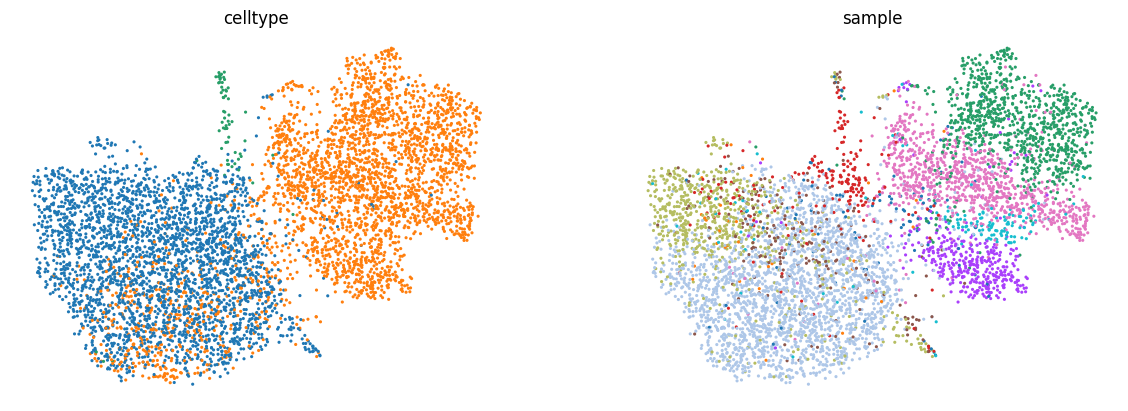

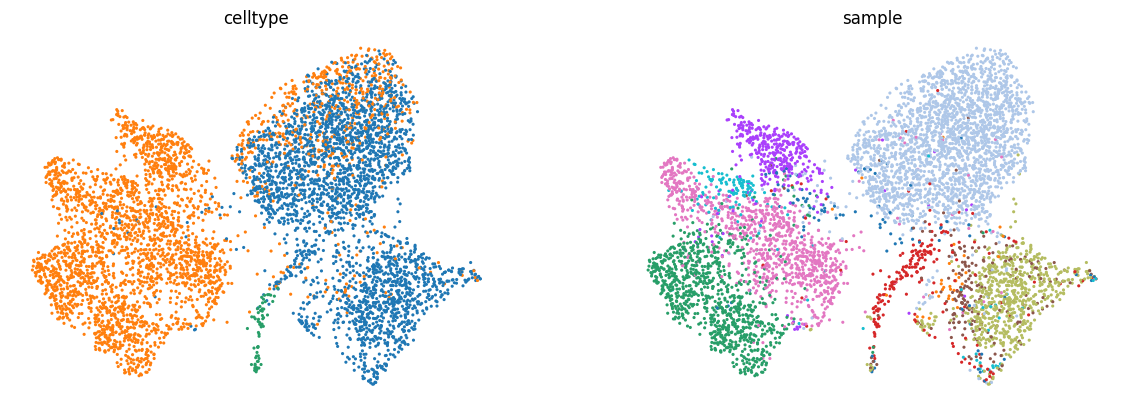

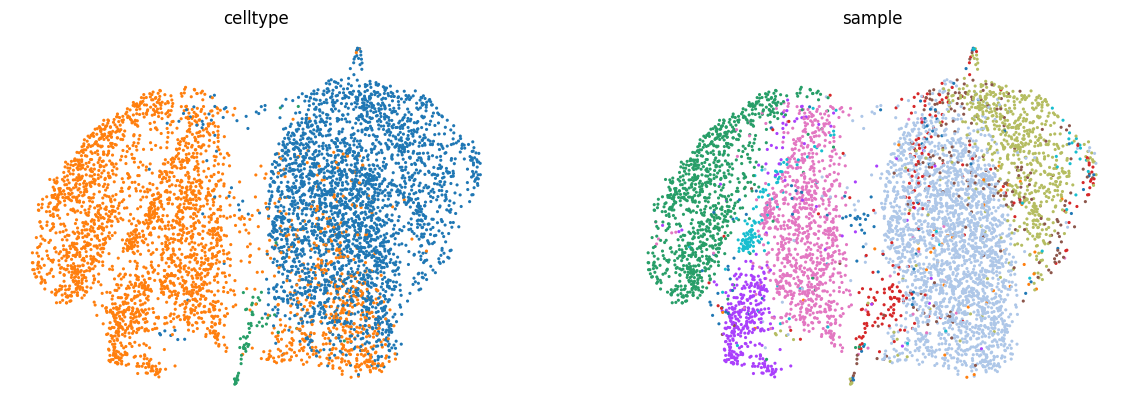

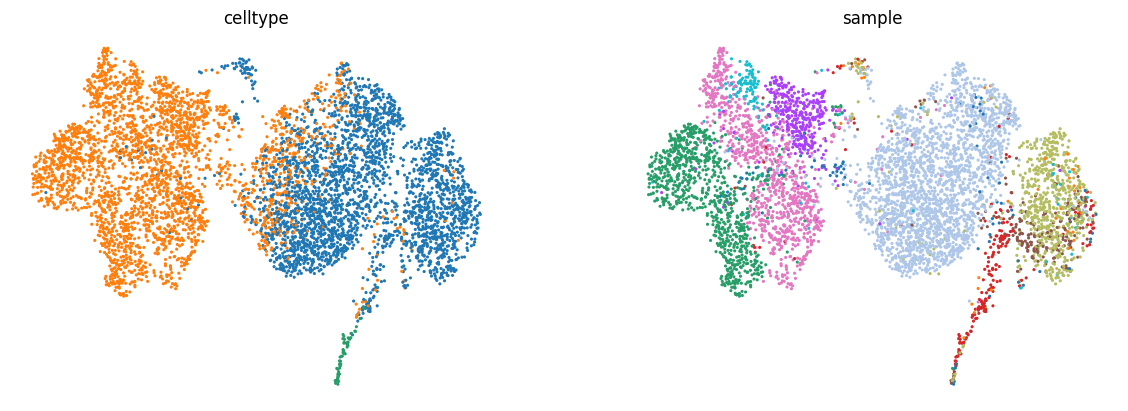

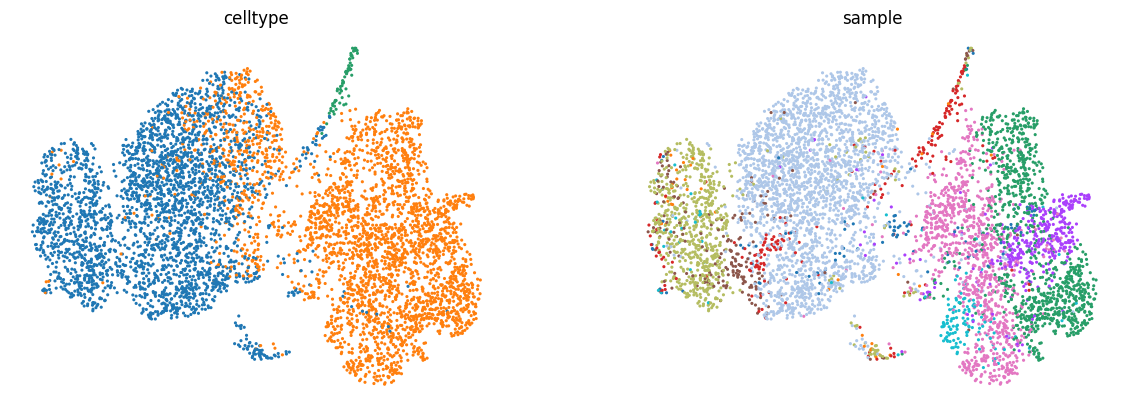

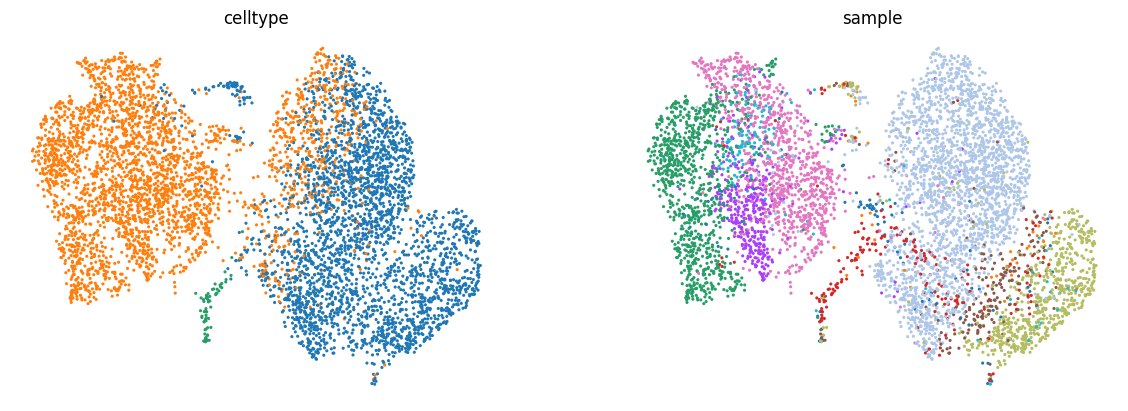

In [5]:
## Generate plots
os.makedirs("./figures/" + dataset, exist_ok=True)
for rep in all_keys:
    sc.pp.neighbors(adata, use_rep=rep)
    sc.tl.umap(adata)
    fig = sc.pl.umap(adata, 
            color=["celltype", "sample"], 
            frameon=False, 
            palette=sc.pl.palettes.default_20,
            legend_loc=None,
            return_fig=True)
    fig.savefig(f"figures/{dataset}/{rep}_umap.png", dpi=300, bbox_inches="tight")

In [39]:
# results may vary slightly given differnet seeds
bio_conservation = BioConservation(nmi_ari_cluster_labels_kmeans=False, nmi_ari_cluster_labels_leiden=True)
batch_correction = BatchCorrection(pcr_comparison=False)

bm = Benchmarker(
    adata,
    batch_key="sample",
    label_key="celltype",
    embedding_obsm_keys=all_keys,
    n_jobs=6,
    bio_conservation_metrics = bio_conservation,
    batch_correction_metrics=batch_correction,
)
bm.benchmark()

/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
Embeddings:   0%|          | 0/6 [00:00<?, ?it/s]/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/local/home/rvander/miniconda3/envs/cancerfoundation2/lib/python3.9/site-packages/scib_metrics/_graph_connectivity.py:30: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
Embeddings: 

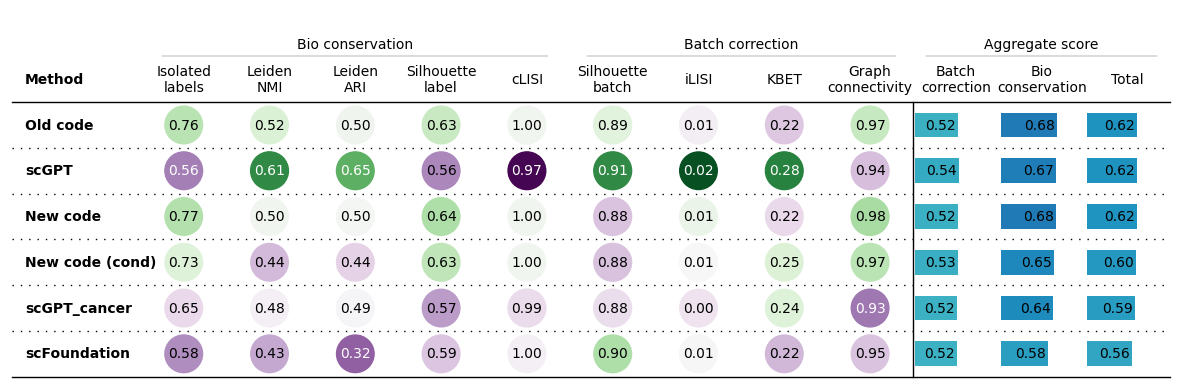

FileNotFoundError: [Errno 2] No such file or directory: './figures/kim_lung/scib_results.svg'

In [40]:
bm.plot_results_table(min_max_scale=False, save_dir="./figures/" + dataset)